# OHCA Clustering Analysis in Google Colab

This notebook performs clustering analysis on synthetic OHCA event points and provides map-ready outputs for instruction.

## What this notebook covers
1. Load synthetic OHCA points.
2. Load county boundaries and keep Georgia counties only.
3. Keep OHCA points that fall within Georgia counties.
4. Run point-based clustering with DBSCAN (spatial density clusters).
5. (Optional) Run KMeans for comparison.
6. Export cluster outputs for mapping and slides.

## 1. Install Packages

In [1]:
!pip -q install geopandas scikit-learn matplotlib folium contextily

## 2. Imports and File Paths

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, KMeans

LOCAL_DATA_DIR = Path('/Users/jenny/Desktop/Workshop/data')
COLAB_DATA_DIR = Path('/content/data')
DATA_DIR = COLAB_DATA_DIR if COLAB_DATA_DIR.exists() else LOCAL_DATA_DIR

OHCA_CSV = DATA_DIR / 'ohca_connected_data_synthetic.csv'
COUNTY_SHP = DATA_DIR / 'cb_2018_us_county_500k' / 'cb_2018_us_county_500k - Copy.shp'

print('OHCA file:', OHCA_CSV)
print('County shapefile:', COUNTY_SHP)

OHCA file: /Users/jenny/Desktop/Workshop/data/ohca_connected_data_synthetic.csv
County shapefile: /Users/jenny/Desktop/Workshop/data/cb_2018_us_county_500k/cb_2018_us_county_500k - Copy.shp


## 3. Load OHCA Points

In [3]:
lat_col = 'scene_gps_latitude_escene.11'
lon_col = 'scene_gps_longitude_escene.11'

ohca = pd.read_csv(OHCA_CSV)
ohca[lat_col] = pd.to_numeric(ohca[lat_col], errors='coerce')
ohca[lon_col] = pd.to_numeric(ohca[lon_col], errors='coerce')
ohca = ohca.dropna(subset=[lat_col, lon_col]).copy()

ohca_points = gpd.GeoDataFrame(
    ohca,
    geometry=gpd.points_from_xy(ohca[lon_col], ohca[lat_col]),
    crs='EPSG:4326'
)

print('OHCA points with valid coordinates:', len(ohca_points))
ohca_points[[lat_col, lon_col, 'incident_date']].head()

OHCA points with valid coordinates: 6005


,scene_gps_latitude_escene.11,scene_gps_longitude_escene.11,incident_date
0,33.720626,-84.233276,2020-05-16
1,34.853186,-84.343906,2021-07-29
2,32.108308,-81.551837,2020-10-26
3,33.716513,-84.317138,2019-11-24
4,33.942115,-83.413094,2021-12-22


## 4. Load Georgia Counties and Keep OHCA Points Within Georgia

In [4]:
county = gpd.read_file(COUNTY_SHP).to_crs('EPSG:4326')

county_id_col = 'GEOID'
county_name_col = 'NAME'
state_col = 'STATEFP'

ga_counties = county[county[state_col].astype(str) == '13'][[county_id_col, county_name_col, 'geometry']].copy()

ohca_ga = gpd.sjoin(
    ohca_points,
    ga_counties,
    how='inner',
    predicate='within'
).drop(columns=['index_right'], errors='ignore')

print('Georgia counties:', len(ga_counties))
print('OHCA points inside Georgia counties:', len(ohca_ga))

Georgia counties: 159
OHCA points inside Georgia counties: 5963


## 5. Quick Map: Georgia Counties + OHCA Points

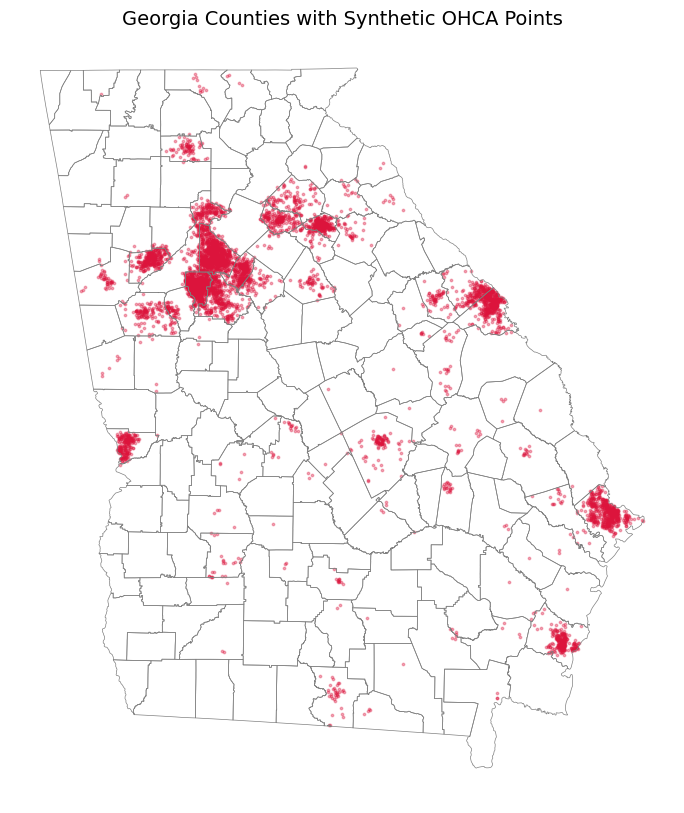

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))
ga_counties.boundary.plot(ax=ax, linewidth=0.5, color='gray')
ohca_ga.plot(ax=ax, markersize=3, color='crimson', alpha=0.35)
ax.set_title('Georgia Counties with Synthetic OHCA Points', fontsize=14)
ax.axis('off')
plt.show()

## 6. Prepare Coordinates for Clustering

DBSCAN distance uses units of the coordinate system. We project to EPSG:3857 so distances are in meters.

In [6]:
ohca_ga_3857 = ohca_ga.to_crs('EPSG:3857').copy()
coords = np.column_stack([ohca_ga_3857.geometry.x.values, ohca_ga_3857.geometry.y.values])

print('Coordinate matrix shape:', coords.shape)

Coordinate matrix shape: (5963, 2)


## 7. DBSCAN Clustering

Tune these parameters for your workshop example:
- `eps` is neighborhood radius in meters.
- `min_samples` is the minimum number of nearby points to form a cluster.

In [7]:
dbscan = DBSCAN(eps=5000, min_samples=10)  # 5 km radius, minimum 10 points
ohca_ga_3857['dbscan_cluster'] = dbscan.fit_predict(coords)
ohca_ga['dbscan_cluster'] = ohca_ga_3857['dbscan_cluster'].values

cluster_counts = ohca_ga['dbscan_cluster'].value_counts().sort_index()
print('DBSCAN cluster label counts (label -1 = noise):')
print(cluster_counts)

num_clusters = len([c for c in cluster_counts.index if c != -1])
print('Number of non-noise clusters:', num_clusters)

DBSCAN cluster label counts (label -1 = noise):
dbscan_cluster
-1      485
 0     2645
 1      553
 2      544
 3      280
 4      207
 5       53
 6      237
 7      502
 8       26
 9      159
 10      38
 11      65
 12      10
 13      19
 14      46
 15      35
 16      17
 17      19
 18      10
 19      13
Name: count, dtype: int64
Number of non-noise clusters: 20


## 8. Map DBSCAN Clusters

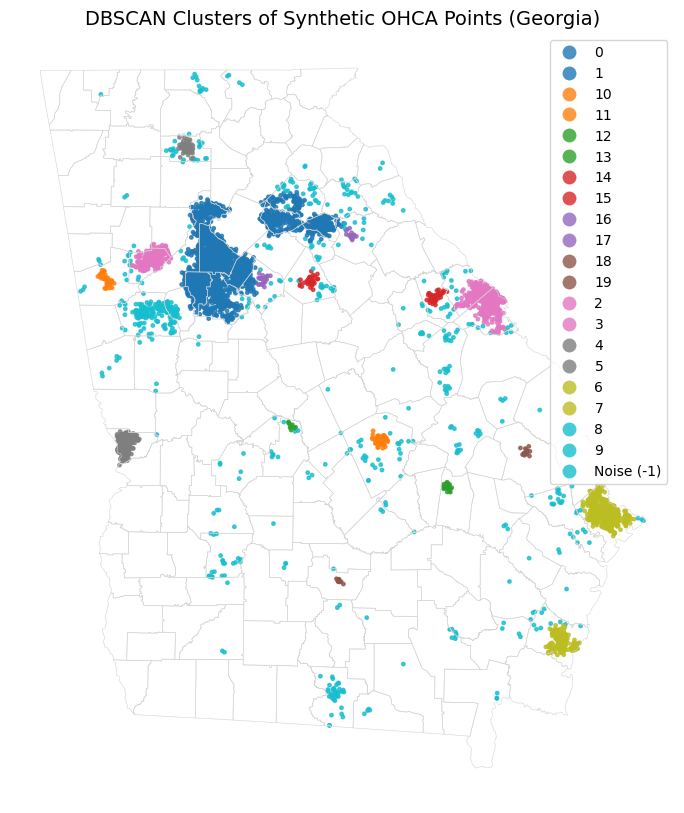

In [8]:
plot_df = ohca_ga.copy()
plot_df['cluster_plot'] = plot_df['dbscan_cluster'].astype(str)
plot_df.loc[plot_df['dbscan_cluster'] == -1, 'cluster_plot'] = 'Noise (-1)'

fig, ax = plt.subplots(figsize=(10, 10))
ga_counties.boundary.plot(ax=ax, linewidth=0.4, color='lightgray')
plot_df.plot(
    ax=ax,
    column='cluster_plot',
    categorical=True,
    markersize=6,
    legend=True,
    alpha=0.8
)
ax.set_title('DBSCAN Clusters of Synthetic OHCA Points (Georgia)', fontsize=14)
ax.axis('off')
plt.show()

## 9. Optional: KMeans Clustering (Teaching Comparison)

KMeans always assigns points to a fixed number of clusters and does not produce noise points.
Use this to compare conceptual differences with DBSCAN.

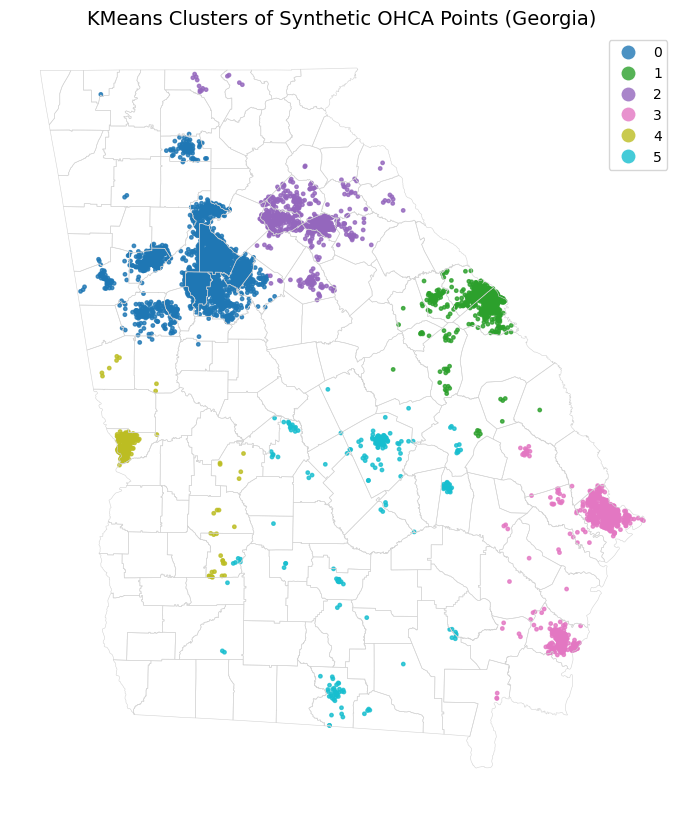

In [9]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=20)
ohca_ga_3857['kmeans_cluster'] = kmeans.fit_predict(coords)
ohca_ga['kmeans_cluster'] = ohca_ga_3857['kmeans_cluster'].values

fig, ax = plt.subplots(figsize=(10, 10))
ga_counties.boundary.plot(ax=ax, linewidth=0.4, color='lightgray')
ohca_ga.plot(
    ax=ax,
    column='kmeans_cluster',
    categorical=True,
    markersize=6,
    legend=True,
    alpha=0.8
)
ax.set_title('KMeans Clusters of Synthetic OHCA Points (Georgia)', fontsize=14)
ax.axis('off')
plt.show()

## 10. County-Level Summary by DBSCAN Cluster

This creates a county summary table of cluster-assigned OHCA points.

In [10]:
county_cluster_summary = (
    ohca_ga.groupby([county_id_col, county_name_col, 'dbscan_cluster'])
    .size()
    .rename('event_count')
    .reset_index()
    .sort_values(['dbscan_cluster', 'event_count'], ascending=[True, False])
)

county_cluster_summary.head(20)

,GEOID,NAME,dbscan_cluster,event_count
69,13157,Jackson,-1,29
30,13077,Coweta,-1,26
72,13163,Jefferson,-1,26
75,13175,Laurens,-1,26
8,13029,Bryan,-1,22
77,13177,Lee,-1,22
104,13227,Pickens,-1,20
86,13195,Madison,-1,18
90,13211,Morgan,-1,17
42,13107,Emanuel,-1,16


## 11. Export Outputs

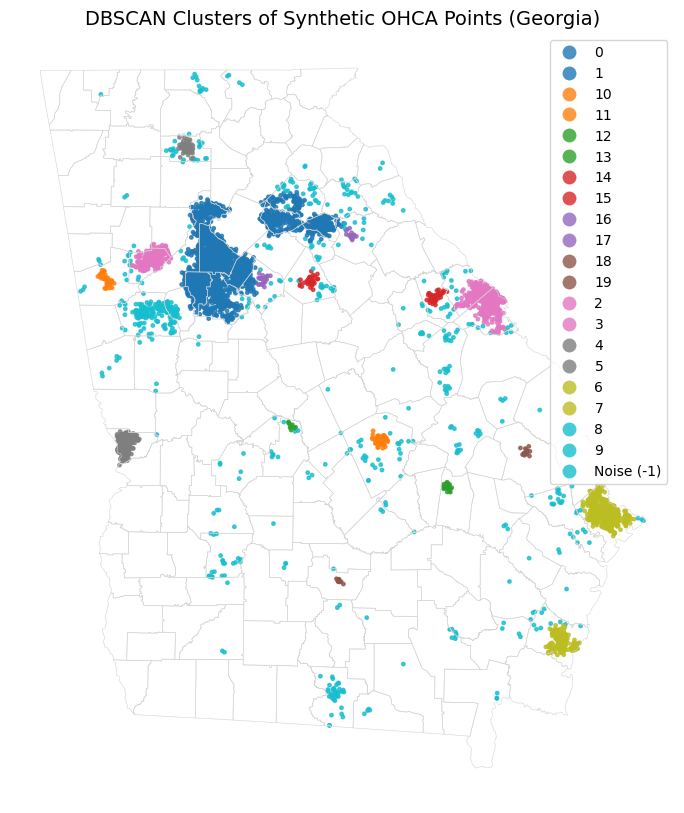

Saved clustered points: /Users/jenny/Desktop/Workshop/data/outputs/ohca_points_clustered.geojson
Saved county cluster summary: /Users/jenny/Desktop/Workshop/data/outputs/ohca_county_cluster_summary.csv
Saved DBSCAN map image: /Users/jenny/Desktop/Workshop/data/outputs/ohca_dbscan_cluster_map.png


In [11]:
OUTPUT_DIR = DATA_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

points_out = OUTPUT_DIR / 'ohca_points_clustered.geojson'
summary_out = OUTPUT_DIR / 'ohca_county_cluster_summary.csv'
png_out = OUTPUT_DIR / 'ohca_dbscan_cluster_map.png'

ohca_ga.to_file(points_out, driver='GeoJSON')
county_cluster_summary.to_csv(summary_out, index=False)

# Save DBSCAN map image
fig, ax = plt.subplots(figsize=(10, 10))
ga_counties.boundary.plot(ax=ax, linewidth=0.4, color='lightgray')
plot_df.plot(
    ax=ax,
    column='cluster_plot',
    categorical=True,
    markersize=6,
    legend=True,
    alpha=0.8
)
ax.set_title('DBSCAN Clusters of Synthetic OHCA Points (Georgia)', fontsize=14)
ax.axis('off')
fig.savefig(png_out, dpi=300, bbox_inches='tight')
plt.show()

print('Saved clustered points:', points_out)
print('Saved county cluster summary:', summary_out)
print('Saved DBSCAN map image:', png_out)

## Notes

- **DBSCAN** is useful for density-based event clustering and identifies noise points.
- **KMeans** is useful for partitioning points into a fixed number of groups.
- For public health interpretation, compare cluster locations with county context variables.